# Hybrid glider vs. Single-Sensor Defender (N=1) with Sea-Skimming

This notebook extends `hybrid_glider_SSG_multisensor_landscape` with the
following structural changes so the attacker can actually exploit terrain:

| Change | What |
|--------|------|
| **N_SENSORS = 1** | single-sensor defender (placement landscape is 1-D) |
| **Powered domain extended** | `zmax = Z_GOAL` (was 300 m). Powered phase can now fly all the way under the ridge. |
| **Switch point freed** | `z_sw ∈ [100, Z_GOAL−100]`, including past the ridge. |
| **Glide ceiling relaxed** | no `h_sw + hh` cap; glide can zoom-climb to clear obstacles. |
| **Terrain collision constraint** | `h ≥ TERR(z) + clearance` applied in both powered and glide DPs (no more flying through hills). |
| **Hill near launch** | `z_ridge = 600` m (between attacker and defender perimeter) so the ridge actually provides ingress cover. |
| **γ > 0 already in grid** | glide γ ∈ [−90°, +45°] — zoom-climb pop-over is allowed; stall floor `V_STALL` enforces physical energy bookkeeping. |

The three plots at the end report:

1. **Plot 1** — *z-h trajectory*: hill profile, attacker BR (powered + glide), switch point, SSE sensor.
2. **Plot 2** — *Cumulative PoD per channel along the SSE attacker BR*: Doppler, RCS, Acoustic shown separately, plus their Poisson-fused total.
3. **Plot 3** — *Placement landscape*: P_D, Coverage, J_D vs single-sensor position z_d.

In [1]:
import math, time, heapq, itertools
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Constants — vehicle, mission, defender (N=1), threat, objectives, sea-skimming setup

In [2]:
# --- physics / vehicle ---
G, RHO = 9.81, 1.225
M, S, CD = 1.5, 0.1, 0.025
CL_DISCRETE = tuple(np.linspace(0.1, 1.5, 10))
V_STALL, V_MAX = 14.0, 100.0
T_MAX = 25.0
THRUST_LEVELS = (0.0, T_MAX)

# --- mission geometry ---
Z_LAUNCH, H_LAUNCH = 0.0, 0.0
V_LAUNCH, GAM_LAUNCH = V_STALL, math.radians(10.0)
Z_GOAL, H_GOAL = 2500.0, 0.0
DT_GLIDE, DT_POW = 1.0, 1.0   # DT_POW raised so dt*v ~ dz/2 (snap advances)
V_MAX_GLIDE = 60.0

# --- DEFENDER (N=1) — perimeter past the ridge only ---
N_SENSORS   = 2
# D_SITES     = np.array([1500.0, 1750.0, 2000.0, 2250.0, 2500.0])
D_SITES     = np.linspace(500, 2500.0, 21)
CORRIDOR_Z0 = 1500.0
R_DET       = 600.0

# --- threat model (channel intensities) ---
LAM_DOPPLER  = 4.5e2
LAM_RCS      = 6.0e3
SIGMA0, SIGMA_MIN = 1.0, 0.1
LAM_ACOUSTIC = 1.0e-2
N_ACOUSTIC   = 4
R_FLOOR      = 10.0

# --- objectives ---
A1_PD, A2_T   = 1.0, 0.002
B1_PD, B2_COV = 1.0, 0.5

# --- glide cost shaping ---
W_TIME_GLIDE = 0.005
W_SMOOTH     = 0.1
W_SPEED      = 1.5
H_CLEAR      = 15.0
Z_FLARE      = 300.0
H_HEADROOM_G = 250.0   # generous: allows zoom-climb pop-over

# --- powered cost shaping ---
W_TIME_POW = 0.005
W_FUEL_POW = 0.001

# --- TERRAIN (mid-corridor ridge between attacker and defenders) ---
RIDGE_HR   = 100.0
RIDGE_ZR   = 1100.0     # mid-corridor, on launch side of all defenders
RIDGE_W    = 350.0
MAST       = 0.0
ACOUST_OCC = 0.05       # strong attenuation when LOS-occluded
TERR_CLEAR = 5.0

# --- switch & BR ---
N_SWITCH   = 12
V_SW_FLOOR = 18.0
TIE_EPS    = 1e-3

# --- DP grids ---
# POW_GRID   = dict(dz=75.0, dh=20.0, dv=8.0, dgam=math.radians(8.0),
#                   zmax=Z_GOAL, hmax=180.0)
POW_GRID   = dict(dz=25.0, dh=20.0, dv=5.0, dgam=math.radians(2.5),
                  zmax=Z_GOAL, hmax=180.0)
RANK_GRID  = dict(dz=100.0, dh=25.0, dv=8.0, dgam=math.radians(12.0))
FINAL_GRID = dict(dz=75.0, dh=20.0, dv=6.0, dgam=math.radians(10.0))

print(f"N_SENSORS={N_SENSORS}, |D_SITES|={len(D_SITES)} sites: {[float(z) for z in D_SITES]}")
print(f"ridge: h_r={RIDGE_HR} m at z={RIDGE_ZR} m, width {RIDGE_W} m")
print(f"powered domain: z in [0, {POW_GRID['zmax']}], h in [0, {POW_GRID['hmax']}]")

N_SENSORS=2, |D_SITES|=21 sites: [500.0, 600.0, 700.0, 800.0, 900.0, 1000.0, 1100.0, 1200.0, 1300.0, 1400.0, 1500.0, 1600.0, 1700.0, 1800.0, 1900.0, 2000.0, 2100.0, 2200.0, 2300.0, 2400.0, 2500.0]
ridge: h_r=100.0 m at z=1100.0 m, width 350.0 m
powered domain: z in [0, 2500.0], h in [0, 180.0]


## Dynamics (unchanged)

In [3]:
def eom(v, gamma, CL, T):
    s, co = math.sin(gamma), math.cos(gamma)
    q = 0.5 * RHO * v * v * S
    return (v * co,
            v * s,
            -G * s - q * CD / M + T / M,
            q * CL / (M * v) - G * co / v)

def rk4(z, h, v, gamma, CL, dt, T):
    k1 = eom(v, gamma, CL, T)
    k2 = eom(v + k1[2]*dt/2, gamma + k1[3]*dt/2, CL, T)
    k3 = eom(v + k2[2]*dt/2, gamma + k2[3]*dt/2, CL, T)
    k4 = eom(v + k3[2]*dt,   gamma + k3[3]*dt,   CL, T)
    return (z + dt/6*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0]),
            h + dt/6*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1]),
            v + dt/6*(k1[2] + 2*k2[2] + 2*k3[2] + k4[2]),
            gamma + dt/6*(k1[3] + 2*k2[3] + 2*k3[3] + k4[3]))

## Terrain and line-of-sight

`TERR(z)` is a Gaussian ridge near the launch side. `visible(zd, z, h)` is a
skyline LOS test in the (z, h) plane: True iff the sensor-to-vehicle segment
stays above terrain at every intervening range. `terrain_floor(z)` provides the
collision constraint for both powered and glide DPs.

In [4]:
def TERR(z):     return RIDGE_HR * math.exp(-((z - RIDGE_ZR) / RIDGE_W) ** 2)
def sens_h(zd, sensor_h=0.):  return TERR(zd) + MAST

def visible(zd, sh, z, h, n=24):
    if abs(z - zd) < 1e-6: return True
    for i in range(1, n):
        t = i / n
        zp = zd + t * (z - zd)
        h_ray = sh + t * (h - sh)
        if h_ray < TERR(zp) - 1e-9: return False
    return True

def terrain_floor(z):
    t = TERR(z)
    return (t + TERR_CLEAR) if t >= 0.5 else 0.0

## Threat model — per-channel rates with terrain masking

Independent-Poisson fusion: $H = \int(\lambda_\text{dop} + \lambda_\text{rcs} + \lambda_\text{ac})\, dt$,
$P_D = 1 - e^{-H}$. Radar channels return 0 when LOS-occluded; the acoustic
channel attenuates by `ACOUST_OCC` instead of zeroing out (diffraction).

In [5]:
def _range(z, h, sensor):
    r = math.hypot(z - sensor[0], h - sensor[1])
    return r if r > R_FLOOR else R_FLOOR

def doppler_rate(z, h, v, gamma, sensor):
    zd = sensor[0]
    sh = sens_h(zd, sensor[1])
    if not visible(zd, sh, z, h): return 0.0
    r  = _range(z, h, (zd, sh))
    dz, dh = z - zd, h - sh
    vr = (v*math.cos(gamma)*dz + v*math.sin(gamma)*dh) / r
    return LAM_DOPPLER * vr*vr / r**4

def rcs_rate(z, h, v, gamma, sensor):
    zd = sensor[0]
    sh = sens_h(zd, sensor[1])
    if not visible(zd, sh, z, h): return 0.0
    r = _range(z, h, (zd, sh))
    ez, eh = (zd - z) / r, (sh - h) / r
    c = ez * (-math.sin(gamma)) + eh * math.cos(gamma)
    sigma = SIGMA_MIN + (SIGMA0 - SIGMA_MIN) * c * c
    return LAM_RCS * sigma / r**4

def radar_rate(z, h, v, gamma, sensor):
    return doppler_rate(z, h, v, gamma, sensor) + rcs_rate(z, h, v, gamma, sensor)

def acoustic_rate(z, h, v, sensor):
    zd = sensor[0]; sh = sens_h(zd, sensor[1])
    r = _range(z, h, (zd, sh))
    base = LAM_ACOUSTIC * v**N_ACOUSTIC / (r*r)
    sh = sens_h(zd, sensor[1])
    return base * (1.0 if visible(zd, sh, z, h) else ACOUST_OCC)

def hazard_glide(pts, sensors, dt_sub):
    return sum(
        sum(radar_rate(z, h, v, g, s) for s in sensors) * dt_sub
        for (z, h, v, g, _T) in pts[:-1]
    )

def hazard_powered(pts, sensors, dt_sub):
    cost = 0.0
    for (z, h, v, g, T) in pts[:-1]:
        cost += sum(radar_rate(z, h, v, g, s) for s in sensors) * dt_sub
        if T > 0:
            cost += sum(acoustic_rate(z, h, v, s) for s in sensors) * dt_sub
    return cost

def pod_from_hazard(hz): return 1.0 - math.exp(-hz)

## State grids and snapping

In [6]:
def glide_grid(z_sw, h_sw, dz, dh, dv, dgam, hh):
    Z = np.arange(z_sw, Z_GOAL + dz, dz)
    H = np.arange(0.0, max(h_sw + hh, POW_GRID['hmax']) + dh, dh)
    Vv = np.arange(V_STALL, V_MAX_GLIDE + dv, dv)
    Gg = np.arange(math.radians(-90), math.radians(45) + dgam, dgam)
    return dict(Z0=Z[0], H0=H[0], V0=Vv[0], G0=Gg[0],
                dz=dz, dh=dh, dv=dv, dgam=dgam,
                NZ=len(Z), NH=len(H), NV=len(Vv), NG=len(Gg),
                Gam=Gg, V=Vv, Z=Z, H=H)

def pow_grid(dz, dh, dv, dgam, zmax, hmax):
    Z = np.arange(0.0, zmax + dz, dz)
    H = np.arange(0.0, hmax + dh, dh)
    Vv = np.arange(V_STALL, V_MAX + dv, dv)
    Gg = np.arange(math.radians(-90), math.radians(90) + dgam, dgam)
    return dict(Z0=Z[0], H0=H[0], V0=Vv[0], G0=Gg[0],
                dz=dz, dh=dh, dv=dv, dgam=dgam,
                NZ=len(Z), NH=len(H), NV=len(Vv), NG=len(Gg),
                Gam=Gg, V=Vv, Z=Z, H=H)

def snap(gr, z, h, v, gamma):
    iz = int(round((z - gr['Z0']) / gr['dz']))
    ih = int(round((h - gr['H0']) / gr['dh']))
    iv = int(round((v - gr['V0']) / gr['dv']))
    ig = int(round((gamma - gr['G0']) / gr['dgam']))
    if 0 <= iz < gr['NZ'] and 0 <= ih < gr['NH'] and 0 <= iv < gr['NV'] and 0 <= ig < gr['NG']:
        return (iz, ih, iv, ig)
    return None

def minclear(z, hc, zf):
    d = Z_GOAL - z
    if d >= zf: return hc
    if d <= 0:  return 0.0
    return hc * d / zf

## Powered DP — Dijkstra over the **full corridor**, hazard-aware (sea-skimming)

Cost integrates `w_time + w_fuel*T + w_haz*hazard(sensor)` along the path, so
the powered phase trajectory itself routes around exposed regions and prefers
LOS-shielded low-altitude ingress when terrain provides cover. Because the
detection cost now depends on the sensor, **this DP is re-solved per placement**
in the SSE sweep.

In [7]:
def powered_dp(gr, sensors, w_time, w_fuel, w_haz=1.0, w_alt=3.0e-3):
    s0 = snap(gr, Z_LAUNCH, H_LAUNCH, V_LAUNCH, GAM_LAUNCH)
    V = {s0: 0.0}; prev = {}; cont = {s0: (Z_LAUNCH, H_LAUNCH, V_LAUNCH, GAM_LAUNCH)}
    heap = [(0.0, 0, s0)]; cnt = 1; hmax = gr['H'][-1]
    while heap:
        c, _, s = heapq.heappop(heap)
        if c > V.get(s, 1e18) + 1e-9: continue
        z, h, v, gm = cont[s]
        for T in THRUST_LEVELS:
            base = w_time * DT_POW + w_fuel * T * DT_POW
            for CL in CL_DISCRETE:
                zn, hn, vn, gn = rk4(z, h, v, gm, CL, DT_POW, T)
                if hn < 0 or zn < 0 or vn < V_STALL or hn > hmax: continue
                if hn < terrain_floor(zn): continue          # terrain collision
                sn = snap(gr, zn, hn, vn, gn)
                if sn is None: continue
                # detection hazard along this transition (linear surrogate for P_D)
                haz = sum(radar_rate(zn, hn, vn, gn, sn_) for sn_ in sensors) * DT_POW
                if T > 0:
                    haz += sum(acoustic_rate(zn, hn, vn, sn_) for sn_ in sensors) * DT_POW
                # small altitude penalty: surrogate for unmodelled low-altitude survivability
                # benefits (multipath, ground clutter, radar horizon). Drives the powered
                # trajectory to nap-of-earth where terrain allows.
                alt_pen = w_alt * hn * DT_POW
                nc = c + base + w_haz * haz + alt_pen
                if nc < V.get(sn, 1e18):
                    V[sn] = nc; prev[sn] = (s, CL, T); cont[sn] = (zn, hn, vn, gn)
                    heapq.heappush(heap, (nc, cnt, sn)); cnt += 1
    return V, prev, cont, s0

def handoff_at(gr, V, cont, z_sw, h_sw):
    izp = int(round((z_sw - gr['Z0']) / gr['dz']))
    ihp = int(round((h_sw - gr['H0']) / gr['dh']))
    if not (0 <= izp < gr['NZ'] and 0 <= ihp < gr['NH']): return None
    best, bv = None, 1e18
    for iv in range(gr['NV']):
        for ig in range(gr['NG']):
            if gr['Gam'][ig] > 1e-9: continue  # only level/descending at handoff
            s = (izp, ihp, iv, ig)
            if s in V and V[s] < bv: bv, best = V[s], s
    if best is None: return None
    z, h, v, g = cont[best]
    return dict(state=best, z=z, h=h, v=v, gamma=g, cost=bv)   # <-- added z, h

## Glide DP — relaxed ceiling, terrain-aware

Ceiling is the full grid `hmax` (no artificial `h_sw + hh` cap), and a state is
rejected if it would put the vehicle below `max(minclear, terrain_floor)`. With
`gamma_max = +45°` already in the grid, the glider can zoom-climb to pop over
the ridge whenever it has the energy to do so without stalling.

In [8]:
def glide_dp(gr, z_sw, h_sw, v_sw, g_sw, sensors, w_time, w_smooth, w_speed,
             hc, zf, hh, use_radar=True):
    s0 = snap(gr, z_sw, h_sw, v_sw, g_sw)
    if s0 is None: return None
    izg = gr['NZ'] - 1
    V = {s0: 0.0}; prev = {}; cont = {s0: (z_sw, h_sw, v_sw, g_sw)}
    heap = [(0.0, 0, s0)]; cnt = 1
    ceil = gr['H'][-1]                        # full grid ceiling (no h_sw+hh cap)
    goal = None
    while heap:
        c, _, s = heapq.heappop(heap)
        if c > V.get(s, 1e18) + 1e-9: continue
        if s[0] == izg and s[1] == 0: goal = s; break
        z, h, v, gm = cont[s]
        pr = sum(radar_rate(z, h, v, gm, sen) for sen in sensors) if use_radar else 0.0
        for CL in CL_DISCRETE:
            zn, hn, vn, gn = rk4(z, h, v, gm, CL, DT_GLIDE, 0.0)
            if zn < z_sw or vn < V_STALL or hn > ceil: continue
            tf = max(minclear(zn, hc, zf), terrain_floor(zn))
            if hn < tf - 1e-9: continue
            sn = snap(gr, zn, hn, vn, gn)
            if sn is None: continue
            nc = c + pr*DT_GLIDE + w_time*DT_GLIDE + w_smooth*abs(gn - gm) + w_speed*abs(vn - v)
            if nc < V.get(sn, 1e18):
                V[sn] = nc; prev[sn] = (s, CL); cont[sn] = (zn, hn, vn, gn)
                heapq.heappush(heap, (nc, cnt, sn)); cnt += 1
    return V, prev, cont, s0, goal

## Switch candidates — freed across the corridor

Sweeps `z_sw ∈ {100, 200, …, Z_GOAL−100}` and a few `h_sw` per `z_sw`, then
decimates to `N_SWITCH`. Includes late switches (past the ridge) needed for
sea-skimming strategies.

In [9]:
def switch_candidates(grp, Vp, contp):
    raw = []
    z_grid = list(np.arange(100.0, Z_GOAL - 100.0 + 1, 200.0))
    h_grid = [20.0, 60.0, 120.0, 200.0]
    for z_sw in z_grid:
        for h_sw in h_grid:
            if h_sw < terrain_floor(z_sw) + 5.0: continue
            ho = handoff_at(grp, Vp, contp, z_sw, h_sw)
            if ho is None or ho['v'] < V_SW_FLOOR: continue
            raw.append((z_sw, h_sw, ho))
    if len(raw) > N_SWITCH:
        idx = np.linspace(0, len(raw) - 1, N_SWITCH).round().astype(int)
        return [raw[i] for i in sorted(set(idx))]
    return raw

## Coverage and defender objective (N=1 reduces to a single interval)

In [10]:
def coverage(sensors):
    intervals = []
    for s in sensors:
        lo = max(CORRIDOR_Z0, s[0] - R_DET)
        hi = min(Z_GOAL,      s[0] + R_DET)
        if hi > lo:
            intervals.append((lo, hi))
    if not intervals: return 0.0
    intervals.sort()
    merged = [list(intervals[0])]
    for lo, hi in intervals[1:]:
        if lo <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], hi)
        else:
            merged.append([lo, hi])
    total = sum(hi - lo for lo, hi in merged)
    return total / (Z_GOAL - CORRIDOR_Z0)

def J_D(P_D, sensors):
    return B1_PD * P_D + B2_COV * coverage(sensors)

## Reconstruct smooth trajectories

In [11]:
def reconstruct(prev, cont, s_goal, s0, dt, T_is_stored, substeps=8):
    seq = []; s = s_goal
    while s != s0 and s in prev:
        e = prev[s]
        if T_is_stored: ps, CL, Tt = e
        else:           ps, CL = e; Tt = 0.0
        seq.append((CL, Tt)); s = ps
    seq.reverse()
    z, h, v, g = cont[s0]; sub = dt / substeps
    pts = [(z, h, v, g, 0.0)]
    for CL, Tt in seq:
        for _ in range(substeps):
            z, h, v, g = rk4(z, h, v, g, CL, sub, Tt)
            pts.append((z, h, v, g, Tt))
    return pts

def count_steps(prev, s0, s_goal):
    n, s = 0, s_goal
    while s != s0 and s in prev:
        n += 1; s = prev[s][0]
    return n

## Attacker best response — full strategy space (early switch, sea-skimming, pop-over)

In [12]:
def attacker_BR(sensors, grp, Vp, prevp, contp, s0p, cands, grid=None, substeps=6,
                use_radar=True):
    grid = grid or RANK_GRID
    evals = []
    for z_sw, h_sw, ho in cands:
        # use the ACTUAL continuous handoff position, not the nominal grid request
        z_hand, h_hand = ho['z'], ho['h']                                  # <-- changed
        gr = glide_grid(z_hand, h_hand, hh=H_HEADROOM_G, **grid)           # <-- changed
        out = glide_dp(gr, z_hand, h_hand, ho['v'], ho['gamma'], sensors,  # <-- changed
                       W_TIME_GLIDE, W_SMOOTH, W_SPEED, H_CLEAR, Z_FLARE, H_HEADROOM_G,
                       use_radar=use_radar)
        if out is None: continue
        V, prev, cont, s0, best = out
        if best is None: continue
        glide_pts = reconstruct(prev, cont, best, s0, DT_GLIDE, False, substeps=substeps)
        pow_pts   = reconstruct(prevp, contp, ho['state'], s0p, DT_POW, True, substeps=substeps)
        hz = (hazard_glide(glide_pts, sensors, DT_GLIDE/substeps)
              + hazard_powered(pow_pts, sensors, DT_POW/substeps))
        P_D = pod_from_hazard(hz)
        T = (count_steps(prevp, s0p, ho['state'])*DT_POW
             + count_steps(prev, s0, best)*DT_GLIDE)
        J_A = A1_PD*P_D + A2_T*T
        evals.append(dict(J_A=J_A, P_D=P_D, T=T, hz=hz,
                          z_sw=z_hand, h_sw=h_hand,                        # <-- record actual
                          ho=ho, glide_pts=glide_pts, pow_pts=pow_pts))
    if not evals: return None
    jmin = min(e['J_A'] for e in evals)
    tied = [e for e in evals if e['J_A'] <= jmin + TIE_EPS]
    return max(tied, key=lambda e: e['P_D'])

## Step 1 — placement sweep (per-placement hazard-aware powered DP + glide BR)

For each candidate sensor position, solve the hazard-aware powered DP once,
collect feasible switch candidates, then run the glide BR. The headline SSE
is refined with a finer grid for the trajectory plot.

In [13]:
t0 = time.time()
sweep = []
for z_d in D_SITES:
    sensors = [(float(z_d), 0.0)]
    grp = pow_grid(**POW_GRID)
    Vp, prevp, contp, s0p = powered_dp(grp, sensors, W_TIME_POW, W_FUEL_POW, w_haz=1.0)
    cands = switch_candidates(grp, Vp, contp)
    if not cands:
        print(f"  z_d={z_d}: no feasible switch candidates")
        continue
    br = attacker_BR(sensors, grp, Vp, prevp, contp, s0p, cands, grid=RANK_GRID)
    if br is None:
        print(f"  z_d={z_d}: attacker BR infeasible")
        continue
    sweep.append(dict(z_d=float(z_d), sensors=sensors,
                      P_D=br['P_D'], cov=coverage(sensors),
                      J_D=J_D(br['P_D'], sensors), br=br,
                      grp=grp, Vp=Vp, prevp=prevp, contp=contp, s0p=s0p, cands=cands))
    print(f"  z_d={z_d:6.0f}: {len(Vp):>6} powered states, {len(cands):>2} switch cands, "
          f"P_D={br['P_D']:.3f}, switch=({br['z_sw']:.0f},{br['h_sw']:.0f})")
print(f"\nplacement sweep finished in {time.time()-t0:.1f}s")

  z_d=   500: 569672 powered states, 12 switch cands, P_D=0.455, switch=(2299,56)
  z_d=   600: 570970 powered states, 12 switch cands, P_D=0.535, switch=(2092,50)
  z_d=   700: 569356 powered states, 12 switch cands, P_D=0.653, switch=(1688,111)
  z_d=   800: 572362 powered states, 12 switch cands, P_D=0.591, switch=(2106,55)
  z_d=   900: 571312 powered states, 12 switch cands, P_D=0.785, switch=(2289,55)
  z_d=  1000: 569965 powered states, 12 switch cands, P_D=0.493, switch=(2095,110)
  z_d=  1100: 570404 powered states, 12 switch cands, P_D=0.286, switch=(2311,110)
  z_d=  1200: 568764 powered states, 12 switch cands, P_D=0.157, switch=(1492,50)
  z_d=  1300: 568440 powered states, 12 switch cands, P_D=0.226, switch=(2312,56)
  z_d=  1400: 567228 powered states, 12 switch cands, P_D=0.082, switch=(1307,116)
  z_d=  1500: 567029 powered states, 12 switch cands, P_D=0.175, switch=(1495,62)
  z_d=  1600: 566035 powered states, 12 switch cands, P_D=0.115, switch=(1705,15)
  z_d=  1700

## Step 2 — pick the SSE and refine its trajectory

In [14]:
print(f"{'z_d':>6} {'P_D':>7} {'cov':>7} {'J_D':>7} {'switch (z,h)':>16}")
for r in sweep:
    z_sw, h_sw = r['br']['z_sw'], r['br']['h_sw']
    print(f"{r['z_d']:>6.0f} {r['P_D']:>7.3f} {r['cov']:>7.3f} {r['J_D']:>7.3f}  ({z_sw:5.0f},{h_sw:5.0f})")

sse = max(sweep, key=lambda r: r['J_D'])
print()
print(f"=> SSE (coarse): sensor @ z={sse['z_d']:.0f}, J_D={sse['J_D']:.3f}")

# Refine SSE attacker BR with FINAL_GRID using the SAME (hazard-aware) powered DP
br_fine = attacker_BR(sse['sensors'], sse['grp'], sse['Vp'], sse['prevp'], sse['contp'],
                      sse['s0p'], sse['cands'], grid=FINAL_GRID, substeps=8)
print(f"   refined BR: P_D={br_fine['P_D']:.3f}, switch=({br_fine['z_sw']:.0f},{br_fine['h_sw']:.0f})")
sse['br']  = br_fine
sse['P_D'] = br_fine['P_D']
sse['J_D'] = J_D(br_fine['P_D'], sse['sensors'])

   z_d     P_D     cov     J_D     switch (z,h)
   500   0.455   0.000   0.455  ( 2299,   56)
   600   0.535   0.000   0.535  ( 2092,   50)
   700   0.653   0.000   0.653  ( 1688,  111)
   800   0.591   0.000   0.591  ( 2106,   55)
   900   0.785   0.000   0.785  ( 2289,   55)
  1000   0.493   0.100   0.543  ( 2095,  110)
  1100   0.286   0.200   0.386  ( 2311,  110)
  1200   0.157   0.300   0.307  ( 1492,   50)
  1300   0.226   0.400   0.426  ( 2312,   56)
  1400   0.082   0.500   0.332  ( 1307,  116)
  1500   0.175   0.600   0.475  ( 1495,   62)
  1600   0.115   0.700   0.465  ( 1705,   15)
  1700   0.024   0.800   0.424  ( 1489,  116)
  1800   0.032   0.900   0.482  ( 1488,   55)
  1900   0.121   1.000   0.621  ( 1508,  114)
  2000   0.080   1.000   0.580  ( 1089,  117)
  2100   0.099   1.000   0.599  ( 1494,  129)
  2200   0.055   0.900   0.505  ( 1699,   55)
  2300   0.043   0.800   0.443  ( 1699,   55)
  2400   0.072   0.700   0.422  ( 1696,  114)
  2500   0.074   0.600   0.374  

## Plot 1 — z vs h: hill, attacker BR trajectory, optimal sensor position

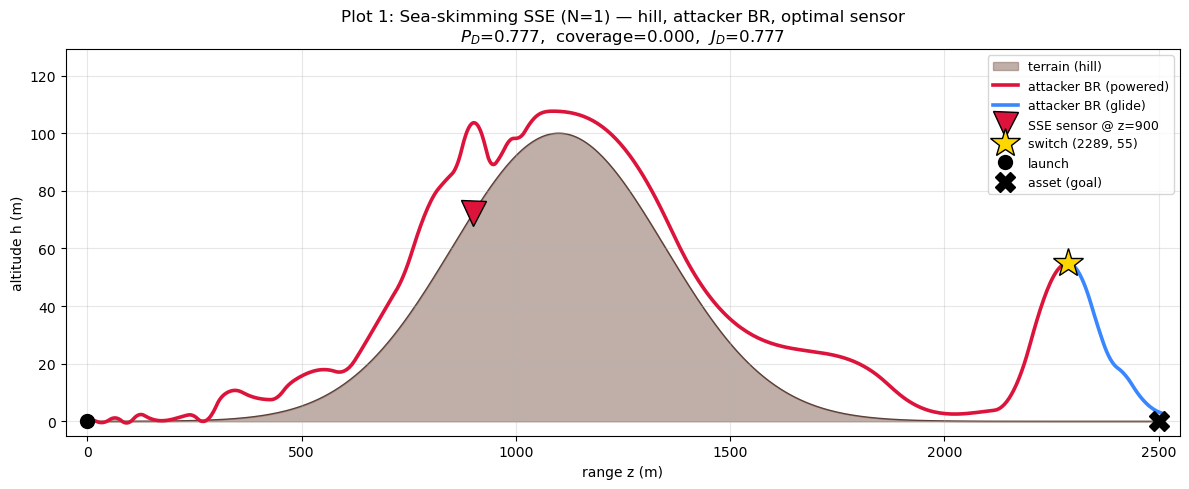

In [15]:
zline = np.linspace(0, Z_GOAL, 400)
hline = np.array([TERR(z) for z in zline])

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(zline, 0, hline, color='#8d6e63', alpha=0.55, zorder=1, label='terrain (hill)')
ax.plot(zline, hline, color='#5d4037', lw=1.0, zorder=1)

pp = np.array([[p[0], p[1]] for p in sse['br']['pow_pts']])
gp = np.array([[p[0], p[1]] for p in sse['br']['glide_pts']])
ax.plot(pp[:,0], pp[:,1], '-', color='crimson',  lw=2.6, zorder=4, label='attacker BR (powered)')
ax.plot(gp[:,0], gp[:,1], '-', color='#3A86FF',  lw=2.6, zorder=4, label='attacker BR (glide)')

for sp in sse['sensors']:
    ax.plot(sp[0], TERR(sp[0]), 'v', color='crimson', ms=18, mec='k', zorder=6,
            label=f'SSE sensor @ z={sp[0]:.0f}')

zs, hs = sse['br']['z_sw'], sse['br']['h_sw']
ax.plot(zs, hs, '*', color='gold', mec='k', ms=22, zorder=7,
        label=f'switch ({zs:.0f}, {hs:.0f})')

ax.plot(Z_LAUNCH, H_LAUNCH, 'ko', ms=10, zorder=6, label='launch')
ax.plot(Z_GOAL,   H_GOAL,   'kX', ms=14, zorder=6, label='asset (goal)')

ax.set_xlabel('range z (m)')
ax.set_ylabel('altitude h (m)')
ax.set_title(f'Plot 1: Sea-skimming SSE (N=1) — hill, attacker BR, optimal sensor\n'
             f'$P_D$={sse["P_D"]:.3f},  coverage={sse["cov"]:.3f},  $J_D$={sse["J_D"]:.3f}')
ax.grid(alpha=0.3)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(-50, Z_GOAL + 50)
ymax = max(np.max(pp[:,1]), np.max(gp[:,1]), RIDGE_HR) * 1.20
ax.set_ylim(-5, ymax)
plt.tight_layout(); plt.show()

## Plot 2 — cumulative PoD per channel along the attacker BR trajectory

For each trajectory point along the SSE attacker BR, accumulate per-channel
hazard $H_j(t) = \int_0^t \lambda_j\, ds$ and report the *cumulative PoD up
to that point*, $P_{D,j}(t) = 1 - e^{-H_j(t)}$, for $j \in \{$Doppler, RCS,
Acoustic$\}$. The total (dashed black) is the Poisson-fused PoD that the
attacker actually optimizes against. Acoustic only accumulates during the
powered phase ($T > 0$).

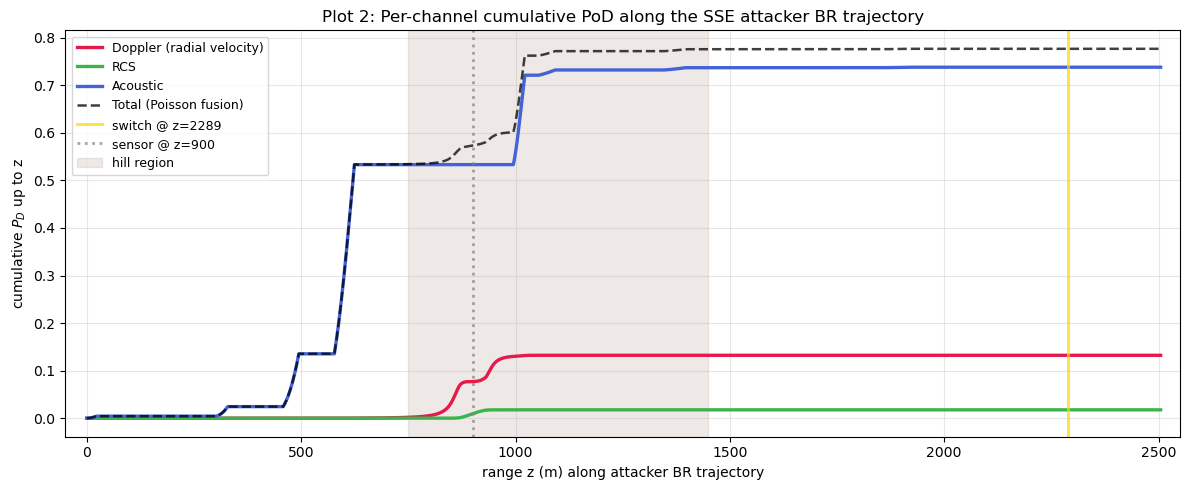

In [16]:
sensor = sse['sensors'][0]
substeps = 8
dt_pow_sub   = DT_POW / substeps
dt_glide_sub = DT_GLIDE / substeps

H_dop = H_rcs = H_ac = 0.0
zs_traj, PDs_dop, PDs_rcs, PDs_ac, PDs_tot = [], [], [], [], []

# powered phase: all three channels (acoustic only when T>0)
for (z, h, v, g, T) in sse['br']['pow_pts'][:-1]:
    lam_d = doppler_rate(z, h, v, g, sensor)
    lam_r = rcs_rate(z, h, v, g, sensor)
    lam_a = acoustic_rate(z, h, v, sensor) if T > 0 else 0.0
    H_dop += lam_d * dt_pow_sub
    H_rcs += lam_r * dt_pow_sub
    H_ac  += lam_a * dt_pow_sub
    zs_traj.append(z)
    PDs_dop.append(1 - math.exp(-H_dop))
    PDs_rcs.append(1 - math.exp(-H_rcs))
    PDs_ac.append (1 - math.exp(-H_ac))
    PDs_tot.append(1 - math.exp(-(H_dop + H_rcs + H_ac)))

# glide phase: radar channels only (no thrust => no acoustic accumulation)
for (z, h, v, g, T) in sse['br']['glide_pts'][:-1]:
    lam_d = doppler_rate(z, h, v, g, sensor)
    lam_r = rcs_rate(z, h, v, g, sensor)
    H_dop += lam_d * dt_glide_sub
    H_rcs += lam_r * dt_glide_sub
    zs_traj.append(z)
    PDs_dop.append(1 - math.exp(-H_dop))
    PDs_rcs.append(1 - math.exp(-H_rcs))
    PDs_ac.append (1 - math.exp(-H_ac))
    PDs_tot.append(1 - math.exp(-(H_dop + H_rcs + H_ac)))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(zs_traj, PDs_dop, color='#e6194B', lw=2.4, label='Doppler (radial velocity)')
ax.plot(zs_traj, PDs_rcs, color='#3cb44b', lw=2.4, label='RCS')
ax.plot(zs_traj, PDs_ac,  color='#4363d8', lw=2.4, label='Acoustic')
ax.plot(zs_traj, PDs_tot, '--', color='black', lw=1.8, alpha=0.75,
        label='Total (Poisson fusion)')
ax.axvline(sse['br']['z_sw'], color='gold', lw=2.2, alpha=0.7,
           label=f"switch @ z={sse['br']['z_sw']:.0f}")
ax.axvline(sse['z_d'], color='gray', lw=2, ls=':', alpha=0.7,
           label=f"sensor @ z={sse['z_d']:.0f}")
ax.axvspan(RIDGE_ZR - RIDGE_W, RIDGE_ZR + RIDGE_W, color='#8d6e63', alpha=0.15,
           label='hill region')

ax.set_xlabel('range z (m) along attacker BR trajectory')
ax.set_ylabel('cumulative $P_D$ up to z')
ax.set_title('Plot 2: Per-channel cumulative PoD along the SSE attacker BR trajectory')
ax.grid(alpha=0.3)
ax.legend(loc='best', fontsize=9)
# ax.set_ylim(-0.02, 1.02)
ax.set_xlim(-50, Z_GOAL + 50)
plt.tight_layout(); plt.show()

## Plot 3 — placement landscape: P_D, Coverage, J_D vs sensor position

For each candidate sensor position $z_d \in $ `D_SITES`, place a single sensor
there and recompute the attacker's best response. Plot the three quantities
(detection probability, coverage fraction, and the defender objective
$J_D = \beta_1 P_D + \beta_2$ Coverage) as functions of $z_d$. The SSE is the
$z_d$ that maximizes $J_D$.

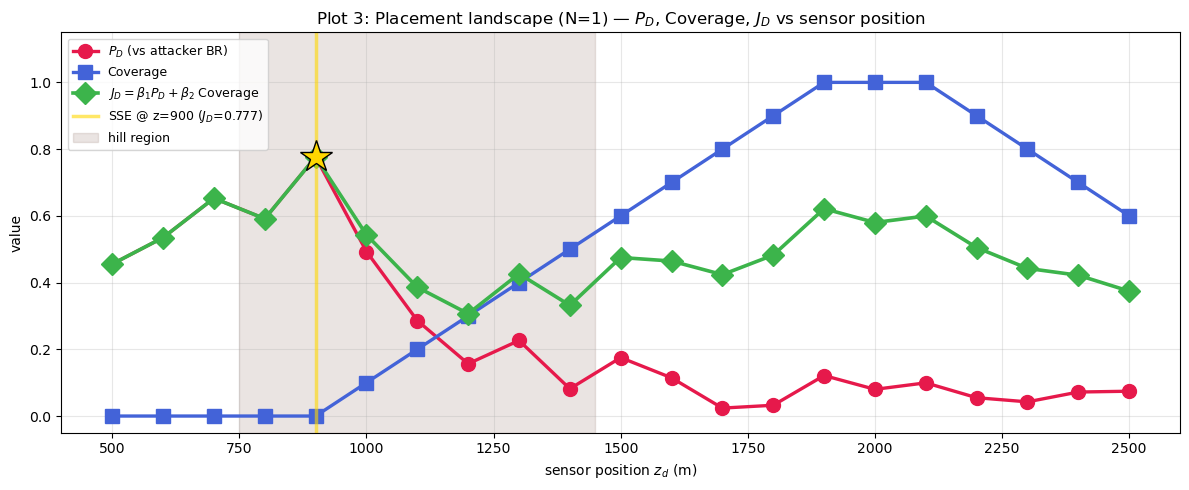

In [17]:
zs_sweep = [r['z_d'] for r in sweep]
pds  = [r['P_D'] for r in sweep]
covs = [r['cov'] for r in sweep]
jds  = [r['J_D'] for r in sweep]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(zs_sweep, pds,  'o-', color='#e6194B', lw=2.4, ms=10, label=r'$P_D$ (vs attacker BR)')
ax.plot(zs_sweep, covs, 's-', color='#4363d8', lw=2.4, ms=10, label='Coverage')
ax.plot(zs_sweep, jds,  'D-', color='#3cb44b', lw=2.6, ms=11,
        label=r'$J_D = \beta_1 P_D + \beta_2$ Coverage')

ax.axvline(sse['z_d'], color='gold', lw=2.5, alpha=0.6,
           label=f"SSE @ z={sse['z_d']:.0f} ($J_D$={sse['J_D']:.3f})")
ax.plot(sse['z_d'], sse['J_D'], '*', color='gold', mec='k', ms=24, zorder=10)

ax.axvspan(RIDGE_ZR - RIDGE_W, RIDGE_ZR + RIDGE_W, color='#8d6e63', alpha=0.18,
           label='hill region')

ax.set_xlabel('sensor position $z_d$ (m)')
ax.set_ylabel('value')
ax.set_title('Plot 3: Placement landscape (N=1) — $P_D$, Coverage, $J_D$ vs sensor position')
ax.grid(alpha=0.3)
ax.legend(loc='best', fontsize=9)
ymax = max(max(jds), max(pds), max(covs)) * 1.15
ax.set_ylim(-0.05, ymax)
plt.tight_layout(); plt.show()

## Step 3 — Fine-grid re-evaluation across all placements

The coarse-grid sweep selects the SSE candidate, but for a defensible fine-grid
SSE we re-evaluate every placement on `FINAL_GRID`. This is the analog of the
relaxation-upper-bound argument used in the airport notebook, but here we do not
assume tightness: the powered domain is full-corridor and switches are placement
dependent, so we recompute the BR on the fine grid directly.

In [18]:
# Re-evaluate every placement's attacker BR on the fine grid using its own
# (hazard-aware) powered DP that was already cached in `sweep`.
t0 = time.time()
fine_rows = []
for r in sweep:
    br_f = attacker_BR(r['sensors'], r['grp'], r['Vp'], r['prevp'], r['contp'],
                       r['s0p'], r['cands'], grid=FINAL_GRID, substeps=8)
    if br_f is None:
        continue
    fine_rows.append(dict(
        z_d=r['z_d'], sensors=r['sensors'],
        P_D_coarse=r['P_D'], P_D=br_f['P_D'],
        cov=coverage(r['sensors']),
        J_D=J_D(br_f['P_D'], r['sensors']),
        br=br_f, grp=r['grp'], Vp=r['Vp'], prevp=r['prevp'],
        contp=r['contp'], s0p=r['s0p'], cands=r['cands'],
    ))
print(f"fine-grid re-evaluation of {len(fine_rows)} placements in {time.time()-t0:.1f}s")

# pick fine-grid SSE
sse_fine = max(fine_rows, key=lambda r: r['J_D'])
print()
print(f"{'z_d':>6} {'P_D (coarse)':>13} {'P_D (fine)':>11} {'cov':>6} {'J_D':>7} {'switch (z,h)':>16}")
for r in fine_rows:
    mark = '  <-- SSE' if r['z_d'] == sse_fine['z_d'] else ''
    print(f"{r['z_d']:>6.0f} {r['P_D_coarse']:>13.3f} {r['P_D']:>11.3f} "
          f"{r['cov']:>6.2f} {r['J_D']:>7.3f}  ({r['br']['z_sw']:5.0f},{r['br']['h_sw']:5.0f}){mark}")
print()
print(f"=> Fine-grid SSE: sensor @ z={sse_fine['z_d']:.0f}, "
      f"P_D={sse_fine['P_D']:.3f}, J_D={sse_fine['J_D']:.3f}")
print(f"   coarse-grid SSE was @ z={sse['z_d']:.0f}, "
      f"coarse->fine same placement? {sse_fine['z_d'] == sse['z_d']}")


fine-grid re-evaluation of 21 placements in 8.5s

   z_d  P_D (coarse)  P_D (fine)    cov     J_D     switch (z,h)
   500         0.455       0.453   0.00   0.453  ( 2299,   56)
   600         0.535       0.530   0.00   0.530  ( 2092,   50)
   700         0.653       0.644   0.00   0.644  ( 1688,  111)
   800         0.591       0.578   0.00   0.578  ( 2309,   50)
   900         0.777       0.777   0.00   0.777  ( 2289,   55)  <-- SSE
  1000         0.493       0.491   0.10   0.541  ( 2095,  110)
  1100         0.286       0.218   0.20   0.318  (  911,  124)
  1200         0.157       0.155   0.30   0.305  ( 1492,   50)
  1300         0.226       0.225   0.40   0.425  ( 2312,   56)
  1400         0.082       0.038   0.50   0.288  (  911,  124)
  1500         0.175       0.093   0.60   0.393  ( 1089,  117)
  1600         0.115       0.114   0.70   0.464  ( 1705,   15)
  1700         0.024       0.022   0.80   0.422  ( 1489,  116)
  1800         0.032       0.029   0.90   0.479  ( 1508, 

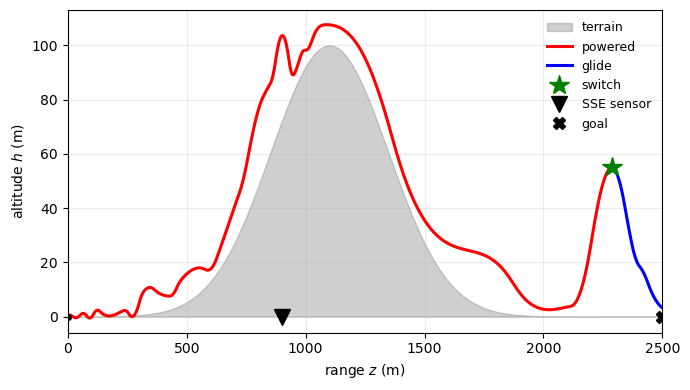

In [19]:
# Fig 2 — skimming z-h trajectory at fine-grid SSE
import matplotlib.pyplot as plt
import numpy as np
GRID_ALPHA = 0.25
SSE_COL, PD_COL, COV_COL, NOM_COL, JD_COL = 'crimson', '#3A86FF', '#2a9d8f', '#E07B39', '#222'
SAVE_KW = dict(dpi=300, bbox_inches='tight')

fig, ax = plt.subplots(figsize=(7, 4))

# Terrain (Gaussian ridge)
zline = np.linspace(0, Z_GOAL, 600)
hr_line = RIDGE_HR * np.exp(-((zline - RIDGE_ZR) / RIDGE_W) ** 2)
ax.fill_between(zline, 0, hr_line, color='#888', alpha=0.4, label='terrain')

# Attacker BR (fine SSE)
brf = sse_fine['br']
pz = [p[0] for p in brf['pow_pts']];   ph = [p[1] for p in brf['pow_pts']]
gz = [p[0] for p in brf['glide_pts']]; gh = [p[1] for p in brf['glide_pts']]
ax.plot(pz, ph, '-', color='r', lw=2.2, label='powered')
ax.plot(gz, gh, '-', color='b', lw=2.2, label='glide')
ax.plot(brf['z_sw'], brf['h_sw'], '*', color='g', ms=15, zorder=6, label='switch')

# SSE sensor
sensor = sse_fine['sensors'][0]
ax.plot(sensor[0], sensor[1], 'v', color='k', ms=11, zorder=6, label='SSE sensor')

# Launch + goal
ax.plot(0, 0, 'o', color='k', ms=4)
ax.plot(Z_GOAL, 0, 'X', color='k', ms=9, label='goal')

ax.set_xlabel(r'range $z$ (m)')
ax.set_ylabel(r'altitude $h$ (m)')
ax.set_xlim(0, Z_GOAL)
ax.legend(fontsize=9, loc='upper right', frameon=False)
ax.grid(alpha=GRID_ALPHA)

plt.tight_layout()
plt.savefig('fig2_skimming_trajectory.pdf', **SAVE_KW)
plt.savefig('fig2_skimming_trajectory.png', **SAVE_KW)
plt.show()

## Step 4 — Nominal-aware (attacker-aware but Stackelberg-blind) baseline

The coverage-greedy/middle baselines do not optimize detection, so the SSE's
gain over them confounds *detection optimization* with *Stackelberg adaptation*.
To isolate the latter we add a stronger baseline: a nominal-aware defender that
maximizes $J_D$ against a *fixed*, sensor-blind, time-optimal attacker (its
trajectory does not depend on the placement). We then score this defender against
the TRUE best-responder on the fine grid.

If the nominal-aware defender selects a different placement from the SSE, the gap
between the two is the value of modeling switch-level best response, beyond
optimizing detection against a nominal path.

In [20]:
# Build the nominal attacker: sensor-blind, time-optimal, placement-independent.
# Use a sensor-blind powered DP (w_haz=0) and a sensor-blind glide (use_radar=False)
# so the trajectory does not depend on any placement.
grp_n = pow_grid(**POW_GRID)
ref_sensor = [(float(D_SITES[len(D_SITES)//2]), 0.0)]   # placeholder; not used in cost
Vp_n, prevp_n, contp_n, s0p_n = powered_dp(grp_n, ref_sensor,
                                            W_TIME_POW, W_FUEL_POW, w_haz=0.0)
cands_n = switch_candidates(grp_n, Vp_n, contp_n)

# Time-optimal glide for each switch candidate; pick globally fastest.
nominal_paths = []
for z_sw, h_sw, ho in cands_n:
    gr = glide_grid(z_sw, h_sw, hh=H_HEADROOM_G, **FINAL_GRID)
    out = glide_dp(gr, z_sw, h_sw, ho['v'], ho['gamma'], ref_sensor,
                   W_TIME_GLIDE, W_SMOOTH, W_SPEED, H_CLEAR, Z_FLARE, H_HEADROOM_G,
                   use_radar=False)
    if out is None: continue
    V, prev, cont, s0, best = out
    if best is None: continue
    gp = reconstruct(prev, cont, best, s0, DT_GLIDE, False, substeps=8)
    pp = reconstruct(prevp_n, contp_n, ho['state'], s0p_n, DT_POW, True, substeps=8)
    T = (count_steps(prevp_n, s0p_n, ho['state'])*DT_POW
         + count_steps(prev, s0, best)*DT_GLIDE)
    nominal_paths.append(dict(gp=gp, pp=pp, T=T, z_sw=z_sw, h_sw=h_sw))

if not nominal_paths:
    raise RuntimeError("No feasible nominal (sensor-blind) trajectory found.")
nominal = min(nominal_paths, key=lambda p: p['T'])
print(f"nominal (sensor-blind) attacker: switch=({nominal['z_sw']:.0f},{nominal['h_sw']:.0f}), T={nominal['T']:.1f} s")

def pd_against_nominal(sensors):
    """Score the nominal (fixed) trajectory against the given placement."""
    hz = (hazard_glide(nominal['gp'], sensors, DT_GLIDE/8)
          + hazard_powered(nominal['pp'], sensors, DT_POW/8))
    return pod_from_hazard(hz)

# Defender best-responds to the nominal (fixed) attacker.
nom_rows = []
for z_d in D_SITES:
    sensors = [(float(z_d), 0.0)]
    pd_n = pd_against_nominal(sensors)
    nom_rows.append(dict(z_d=float(z_d), sensors=sensors,
                         pd_vs_nominal=pd_n,
                         J_D_vs_nominal=B1_PD*pd_n + B2_COV*coverage(sensors)))
nom_best = max(nom_rows, key=lambda r: r['J_D_vs_nominal'])
print(f"nominal-aware defender picks z_d={nom_best['z_d']:.0f}  "
      f"(P_D against nominal = {nom_best['pd_vs_nominal']:.3f}, "
      f"J_D against nominal = {nom_best['J_D_vs_nominal']:.3f})")

# Evaluate the nominal-aware placement against the TRUE best-responder.
nom_row_sweep = next((r for r in fine_rows if r['z_d'] == nom_best['z_d']), None)
if nom_row_sweep is None:
    sensors = nom_best['sensors']
    grp_b = pow_grid(**POW_GRID)
    Vp_b, prevp_b, contp_b, s0p_b = powered_dp(grp_b, sensors,
                                                W_TIME_POW, W_FUEL_POW, w_haz=1.0)
    cands_b = switch_candidates(grp_b, Vp_b, contp_b)
    br_b = attacker_BR(sensors, grp_b, Vp_b, prevp_b, contp_b, s0p_b, cands_b,
                       grid=FINAL_GRID, substeps=8)
    nom_row_sweep = dict(z_d=nom_best['z_d'], sensors=sensors,
                         P_D=br_b['P_D'], cov=coverage(sensors),
                         J_D=J_D(br_b['P_D'], sensors), br=br_b)

print()
print("nominal-aware defender, evaluated against TRUE best-responder (fine grid):")
print(f"  z_d={nom_row_sweep['z_d']:.0f}  P_D={nom_row_sweep['P_D']:.3f}  "
      f"cov={nom_row_sweep['cov']:.2f}  J_D={nom_row_sweep['J_D']:.3f}  "
      f"switch=({nom_row_sweep['br']['z_sw']:.0f},{nom_row_sweep['br']['h_sw']:.0f})")


nominal (sensor-blind) attacker: switch=(2300,60), T=64.0 s
nominal-aware defender picks z_d=1900  (P_D against nominal = 1.000, J_D against nominal = 1.500)

nominal-aware defender, evaluated against TRUE best-responder (fine grid):
  z_d=1900  P_D=0.042  cov=1.00  J_D=0.542  switch=(1508,114)


## Step 5 — Summary comparison and switch-variance diagnostic

Three placements on the fine grid:

- **SSE (game-aware)**: maximizes $J_D$ against the true best-responder.
- **Nominal-aware (Stackelberg-blind)**: maximizes $J_D$ against a fixed sensor-blind
  time-optimal attacker; then scored against the true best-responder.
- **Mid-corridor (naive coverage)**: single sensor at the corridor midpoint.

The gap (SSE J_D) - (nominal-aware J_D) is the value of modeling switch-level
best response. The switch diagnostic reports how many distinct best-response
switches occur across the placement set; if more than one, switch invariance
breaks and Stackelberg adaptation is active.

In [21]:
# Mid-corridor baseline (single sensor at midpoint of D_SITES).
mid_z = float(D_SITES[len(D_SITES)//2])
mid_row = next((r for r in fine_rows if r['z_d'] == mid_z), None)

print(f'{"Strategy":<28}{"z_d":>8}{"P_D":>9}{"cov":>8}{"J_D":>8}{"switch (z,h)":>18}')
print('-' * 79)
for name, r in [('SSE (game-aware)', sse_fine),
                ('Nominal-aware', nom_row_sweep),
                ('Mid-corridor (naive)', mid_row)]:
    if r is None:
        print(f'{name:<28}  (no data)')
        continue
    print(f'{name:<28}{r["z_d"]:>8.0f}{r["P_D"]:>9.3f}{r["cov"]:>8.2f}'
          f'{r["J_D"]:>8.3f}   ({r["br"]["z_sw"]:5.0f},{r["br"]["h_sw"]:5.0f})')

print()
if nom_row_sweep is not None:
    dJ = sse_fine['J_D'] - nom_row_sweep['J_D']
    same = (sse_fine['z_d'] == nom_row_sweep['z_d'])
    print(f"SSE vs nominal-aware: J_D {nom_row_sweep['J_D']:.3f} -> {sse_fine['J_D']:.3f}  "
          f"(gap = {dJ:+.3f}, same placement? {same})")
    print(f"  => game-awareness {'does NOT add value' if same else 'binds'} in this geometry.")

# Switch-invariance diagnostic on the fine grid.
distinct_switches = sorted({(round(r['br']['z_sw'],0), round(r['br']['h_sw'],0))
                            for r in fine_rows})
print()
print(f"Distinct best-response switches across {len(fine_rows)} placements: "
      f"{len(distinct_switches)}")
print(f"  switches: {distinct_switches}")
if len(distinct_switches) > 1:
    print("  => switch invariance is BROKEN: BR switch depends on placement, "
          "Stackelberg adaptation is active.")
else:
    print("  => switch invariance HOLDS: BR switch is constant, game-aware == detection-aware.")


Strategy                         z_d      P_D     cov     J_D      switch (z,h)
-------------------------------------------------------------------------------
SSE (game-aware)                 900    0.777    0.00   0.777   ( 2289,   55)
Nominal-aware                   1900    0.042    1.00   0.542   ( 1508,  114)
Mid-corridor (naive)            1500    0.093    0.60   0.393   ( 1089,  117)

SSE vs nominal-aware: J_D 0.542 -> 0.777  (gap = +0.235, same placement? False)
  => game-awareness binds in this geometry.

Distinct best-response switches across 21 placements: 16
  switches: [(911.0, 124.0), (1089.0, 117.0), (1489.0, 116.0), (1492.0, 50.0), (1503.0, 113.0), (1508.0, 114.0), (1688.0, 111.0), (1699.0, 55.0), (1705.0, 15.0), (1911.0, 10.0), (2092.0, 50.0), (2095.0, 110.0), (2289.0, 55.0), (2299.0, 56.0), (2309.0, 50.0), (2312.0, 56.0)]
  => switch invariance is BROKEN: BR switch depends on placement, Stackelberg adaptation is active.


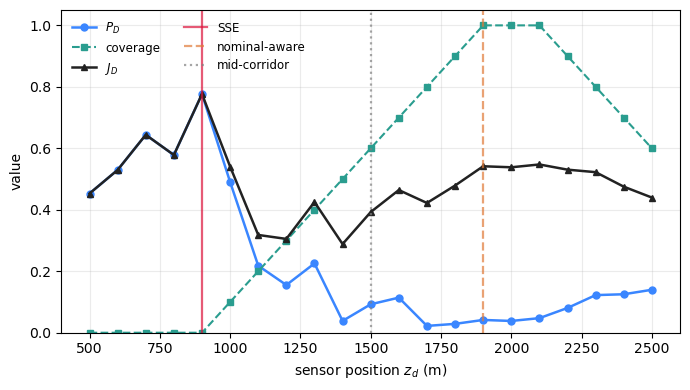

In [22]:
# Fig 3 — skimming placement landscape, SSE / nominal-aware / mid-corridor
import matplotlib.pyplot as plt
GRID_ALPHA = 0.25
SSE_COL, PD_COL, COV_COL, NOM_COL, JD_COL = 'crimson', '#3A86FF', '#2a9d8f', '#E07B39', '#222'
SAVE_KW = dict(dpi=300, bbox_inches='tight')

fig, ax = plt.subplots(figsize=(7, 4))

zs   = [r['z_d'] for r in fine_rows]
pds  = [r['P_D'] for r in fine_rows]
covs = [r['cov'] for r in fine_rows]
jds  = [r['J_D'] for r in fine_rows]

ax.plot(zs, pds,  'o-', color=PD_COL,  lw=1.8, ms=5, label=r'$P_D$')
ax.plot(zs, covs, 's--', color=COV_COL, lw=1.5, ms=4, label='coverage')
ax.plot(zs, jds,  '^-', color=JD_COL,  lw=1.8, ms=5, label=r'$J_D$')

ax.axvline(sse_fine['z_d'],     color=SSE_COL, ls='-',  lw=1.6, alpha=0.7, label='SSE')
ax.axvline(nom_row_sweep['z_d'],color=NOM_COL, ls='--', lw=1.6, alpha=0.7, label='nominal-aware')
ax.axvline(mid_row['z_d'],      color='gray',  ls=':',  lw=1.6, alpha=0.7, label='mid-corridor')

ax.set_xlabel(r'sensor position $z_d$ (m)')
ax.set_ylabel('value')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8.5, frameon=False, ncol=2, loc='upper left')
ax.grid(alpha=GRID_ALPHA)

plt.tight_layout()
plt.savefig('fig3_skimming_landscape.pdf', **SAVE_KW)
plt.savefig('fig3_skimming_landscape.png', **SAVE_KW)
plt.show()

In [23]:
# Quick continuity check after the patch (run once after BR computation)
print(f"powered terminal: ({sse_fine['br']['pow_pts'][-1][0]:.1f}, {sse_fine['br']['pow_pts'][-1][1]:.1f})")
print(f"switch recorded:  ({sse_fine['br']['z_sw']:.1f}, {sse_fine['br']['h_sw']:.1f})")
print(f"glide initial:    ({sse_fine['br']['glide_pts'][0][0]:.1f}, {sse_fine['br']['glide_pts'][0][1]:.1f})")
# expect: powered terminal ≈ switch recorded ≈ glide initial (within RK4 drift, ~1m)

powered terminal: (2288.7, 54.7)
switch recorded:  (2288.6, 55.1)
glide initial:    (2288.6, 55.1)
